In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Scikit-Learn Imports
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# TensorFlow and Keras Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

try:
    import keras_tuner as kt
except ImportError:
    !pip install keras-tuner -q
    import keras_tuner as kt

# Visual Settings
%matplotlib inline
sns.set(style='whitegrid')
warnings.filterwarnings('ignore')
print("Libraries and dependencies imported successfully.")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

Libraries and dependencies imported successfully.


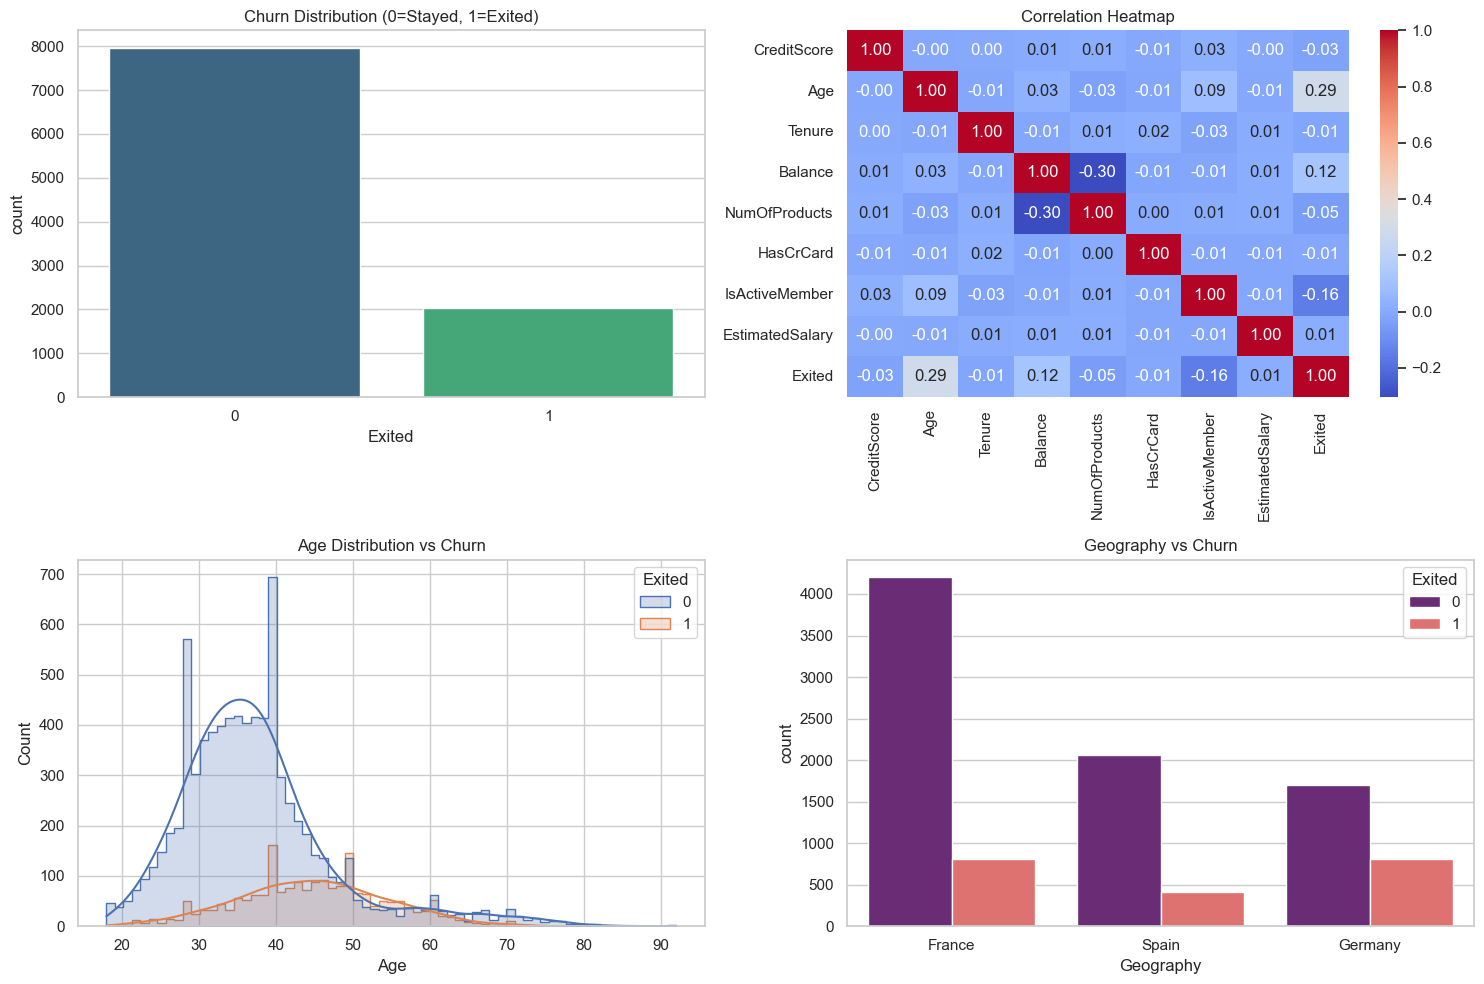

Irrelevant Columns Dropped.
Categorical Encodeing Done.
--- Skewness in Numerical Features ---
CreditScore       -0.071607
Age                1.011320
Tenure             0.010991
Balance           -0.141109
NumOfProducts      0.745568
EstimatedSalary    0.002085
dtype: float64
Outlier Treatment Done.
Train-Test Split Done.
Feature Scaling Done.
--- Final Training Data Shape ---
Final Training Shape: (8000, 11)


In [2]:
# Load the dataset
Bank_Cust_Churn_Data = pd.read_csv('Bank_Customer_Churn.csv')

plt.figure(figsize=(15, 10))

# 1. Target Distribution
plt.subplot(2, 2, 1)
sns.countplot(x='Exited', data=Bank_Cust_Churn_Data, palette='viridis')
plt.title('Churn Distribution (0=Stayed, 1=Exited)')

# 2. Correlation Heatmap
plt.subplot(2, 2, 2)
numeric_df = Bank_Cust_Churn_Data.select_dtypes(include=[np.number]).drop(['RowNumber', 'CustomerId'], axis=1)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

# 3. Age Distribution by Churn
plt.subplot(2, 2, 3)
sns.histplot(data=Bank_Cust_Churn_Data, x='Age', hue='Exited', kde=True, element='step')
plt.title('Age Distribution vs Churn')

# 4. Geography vs Churn
plt.subplot(2, 2, 4)
sns.countplot(x='Geography', hue='Exited', data=Bank_Cust_Churn_Data, palette='magma')
plt.title('Geography vs Churn')

plt.tight_layout()
plt.show()

# 1. Drop Irrelevant Columns
Bank_Cust_Churn_Data = Bank_Cust_Churn_Data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print("Irrelevant Columns Dropped.")

# 2. Categorical Encoding
le = LabelEncoder()
Bank_Cust_Churn_Data['Gender'] = le.fit_transform(Bank_Cust_Churn_Data['Gender'])
Bank_Cust_Churn_Data = pd.get_dummies(Bank_Cust_Churn_Data, columns=['Geography'], drop_first=True)
print("Categorical Encodeing Done.")

# 3. Check for Skewness before capping
print("--- Skewness in Numerical Features ---")
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
print(Bank_Cust_Churn_Data[numerical_cols].skew())

# 4. Outlier Treatment (Capping)
for col in ['Age', 'CreditScore']:
    Q1 = Bank_Cust_Churn_Data[col].quantile(0.25)
    Q3 = Bank_Cust_Churn_Data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    Bank_Cust_Churn_Data[col] = np.clip(Bank_Cust_Churn_Data[col], lower, upper)

print("Outlier Treatment Done.")

# 5. Train-Test Split (BEFORE Scaling to prevent leakage)
X = Bank_Cust_Churn_Data.drop('Exited', axis=1)
y = Bank_Cust_Churn_Data['Exited']
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train-Test Split Done.")

# 6. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
print("Feature Scaling Done.")

print("--- Final Training Data Shape ---")
print(f"Final Training Shape: {X_train.shape}")

In [3]:
# Model Dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

def evaluate_models(X_train, X_test, y_train, y_test, models, label):
    perf_list = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred_test = model.predict(X_test)
        y_prob_test = model.predict_proba(X_test)[:, 1]
        y_pred_train = model.predict(X_train)

        perf_list.append({
            "Model": name,
            "Data Type": label,
            "Train Accuracy": accuracy_score(y_train, y_pred_train),
            "Test Accuracy": accuracy_score(y_test, y_pred_test),
            "Precision": precision_score(y_test, y_pred_test),
            "Recall": recall_score(y_test, y_pred_test),
            "F1 Score": f1_score(y_test, y_pred_test),
            "ROC-AUC": roc_auc_score(y_test, y_prob_test)
        })

    return pd.DataFrame(perf_list).sort_values(by='Test Accuracy', ascending=False)

print("Models and evaluation function updated to include training accuracy.")

Models and evaluation function updated to include training accuracy.


In [4]:
import warnings
warnings.filterwarnings('ignore')

# Running evaluation on imbalanced data
results_imbalanced = evaluate_models(X_train, X_test, y_train, y_test, models, "Imbalanced")

print("--- Experiment 1 Results (Imbalanced Data) ---")
display(results_imbalanced)

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
--- Experiment 1 Results (Imbalanced Data) ---


,Model,Data Type,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Gradient Boosting,Imbalanced,0.871625,0.8715,0.795276,0.496314,0.611195,0.870647
2,Random Forest,Imbalanced,1.000000,0.8655,0.792373,0.459459,0.581649,0.853261
5,LightGBM,Imbalanced,0.912875,0.8635,0.755725,0.486486,0.591928,0.859991
6,SVM,Imbalanced,0.864000,0.8620,0.846561,0.393120,0.536913,0.822695
4,XGBoost,Imbalanced,0.964625,0.8455,0.671329,0.471744,0.554113,0.832298
7,KNN,Imbalanced,0.871250,0.8235,0.617391,0.348894,0.445840,0.754105
0,Logistic Regression,Imbalanced,0.818125,0.8155,0.626667,0.230958,0.337522,0.783383
1,Decision Tree,Imbalanced,1.000000,0.7825,0.468037,0.503686,0.485207,0.678710


In [5]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Note: SMOTE should only be applied to the training data to avoid data leakage
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("--- Class Distribution After SMOTE ---")
print(f"Original training set shape: {Counter(y_train)}")
print(f"Resampled training set shape: {Counter(y_train_res)}")

--- Class Distribution After SMOTE ---
Original training set shape: Counter({0: 6370, 1: 1630})
Resampled training set shape: Counter({1: 6370, 0: 6370})


In [6]:
# Running evaluation on balanced data
results_balanced = evaluate_models(X_train_res, X_test, y_train_res, y_test, models, "Balanced")

print("--- Experiment 2 Results (Balanced Data) ---")
display(results_balanced)

[LightGBM] [Info] Number of positive: 6370, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000904 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1692
[LightGBM] [Info] Number of data points in the train set: 12740, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
--- Experiment 2 Results (Balanced Data) ---


,Model,Data Type,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,LightGBM,Balanced,0.933203,0.8590,0.691131,0.555283,0.615804,0.861641
4,XGBoost,Balanced,0.965306,0.8520,0.659942,0.562654,0.607427,0.836882
3,Gradient Boosting,Balanced,0.880141,0.8455,0.609375,0.670762,0.638596,0.867634
2,Random Forest,Balanced,1.000000,0.8380,0.606138,0.582310,0.593985,0.847610
6,SVM,Balanced,0.830926,0.7950,0.497445,0.717445,0.587525,0.835577
1,Decision Tree,Balanced,1.000000,0.7615,0.428571,0.515971,0.468227,0.670101
7,KNN,Balanced,0.904160,0.7290,0.397260,0.641278,0.490602,0.751511
0,Logistic Regression,Balanced,0.715463,0.7170,0.390646,0.697789,0.500882,0.782667


In [7]:
# 1. Merge the results from both experiments
combined_results = pd.concat([results_imbalanced, results_balanced], axis=0).reset_index(drop=True)

print("--- Combined Model Performance ---")
display(combined_results.sort_values(by='Test Accuracy', ascending=False))

# 2. Dynamically select the top 2 models based on Test Accuracy from the balanced experiment
top_2_models_info = results_balanced.head(2)
top_model_names = top_2_models_info['Model'].tolist()

print("\n--- Top 2 Selected Models (from Balanced Data) ---")
for i, name in enumerate(top_model_names, 1):
    acc = top_2_models_info.iloc[i-1]['Test Accuracy']
    print(f"{i}. {name} (Accuracy: {acc:.4f})")

--- Combined Model Performance ---


,Model,Data Type,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,Imbalanced,0.871625,0.8715,0.795276,0.496314,0.611195,0.870647
1,Random Forest,Imbalanced,1.000000,0.8655,0.792373,0.459459,0.581649,0.853261
2,LightGBM,Imbalanced,0.912875,0.8635,0.755725,0.486486,0.591928,0.859991
3,SVM,Imbalanced,0.864000,0.8620,0.846561,0.393120,0.536913,0.822695
8,LightGBM,Balanced,0.933203,0.8590,0.691131,0.555283,0.615804,0.861641
9,XGBoost,Balanced,0.965306,0.8520,0.659942,0.562654,0.607427,0.836882
4,XGBoost,Imbalanced,0.964625,0.8455,0.671329,0.471744,0.554113,0.832298
10,Gradient Boosting,Balanced,0.880141,0.8455,0.609375,0.670762,0.638596,0.867634
11,Random Forest,Balanced,1.000000,0.8380,0.606138,0.582310,0.593985,0.847610
5,KNN,Imbalanced,0.871250,0.8235,0.617391,0.348894,0.445840,0.754105



--- Top 2 Selected Models (from Balanced Data) ---
1. LightGBM (Accuracy: 0.8590)
2. XGBoost (Accuracy: 0.8520)


In [8]:
from sklearn.model_selection import GridSearchCV

# 1. Hyperparameter Tuning for LightGBM
print("Starting Hyperparameter Tuning for LightGBM...")
lgbm_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 50],
    'boosting_type': ['gbdt']
}

lgbm_grid = GridSearchCV(LGBMClassifier(random_state=42, verbose=-1), lgbm_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
lgbm_grid.fit(X_train_res, y_train_res)

print(f"Best LightGBM Params: {lgbm_grid.best_params_}")
print(f"Best LightGBM CV Accuracy: {lgbm_grid.best_score_:.4f}")

# 2. Hyperparameter Tuning for XGBoost
print("\nStarting Hyperparameter Tuning for XGBoost...")
xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6],
    'eval_metric': ['logloss']
}

xgb_grid = GridSearchCV(XGBClassifier(random_state=42), xgb_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train_res, y_train_res)

print(f"Best XGBoost Params: {xgb_grid.best_params_}")
print(f"Best XGBoost CV Accuracy: {xgb_grid.best_score_:.4f}")

# 3. Store tuned results for final comparison
tuned_lgbm_acc = accuracy_score(y_test, lgbm_grid.predict(X_test))
tuned_xgb_acc = accuracy_score(y_test, xgb_grid.predict(X_test))

print(f"\nTuned LightGBM Test Accuracy: {tuned_lgbm_acc:.4f}")
print(f"Tuned XGBoost Test Accuracy: {tuned_xgb_acc:.4f}")

Starting Hyperparameter Tuning for LightGBM...
Best LightGBM Params: {'boosting_type': 'gbdt', 'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 31}
Best LightGBM CV Accuracy: 0.8710

Starting Hyperparameter Tuning for XGBoost...
Best XGBoost Params: {'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Best XGBoost CV Accuracy: 0.8735

Tuned LightGBM Test Accuracy: 0.8590
Tuned XGBoost Test Accuracy: 0.8595


In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define the ANN architecture
model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,201 (4.69 KB)

 Trainable params: 1,201 (4.69 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Set up callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=1000,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy without Keras Tuner: {test_accuracy}")


Epoch 1/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7730 - loss: 0.5385 - val_accuracy: 0.8000 - val_loss: 0.4574
Epoch 2/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7969 - loss: 0.4659 - val_accuracy: 0.8163 - val_loss: 0.4304
Epoch 3/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8073 - loss: 0.4500 - val_accuracy: 0.8200 - val_loss: 0.4216
Epoch 4/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8106 - loss: 0.4395 - val_accuracy: 0.8438 - val_loss: 0.4108
Epoch 5/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8155 - loss: 0.4285 - val_accuracy: 0.8487 - val_loss: 0.3967
Epoch 6/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8255 - loss: 0.4141 - val_accuracy: 0.8531 - val_loss: 0.3826
Epoch 7/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8273 - loss: 0.4097 - val_accuracy: 0.8506 - val_loss: 0.3803
Epoch 8/1000
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8288 - loss: 0.4045 - 

In [11]:
y_pred=model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [16]:
def build_model(hp):
    model = keras.Sequential()
    # Tune the number of hidden layers
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', min_value=16, max_value=64, step=16),
            activation=hp.Choice('activation', ['relu', 'tanh', 'sigmoid'])
        ))
        model.add(layers.Dropout(hp.Float('dropout', 0, 0.5, step=0.1)))

    model.add(layers.Dense(1, activation='sigmoid'))

    # Tune the optimizer and loss function
    optimizer_choice = hp.Choice('optimizer', ['adam', 'rmsprop', 'sgd'])
    loss_choice = hp.Choice('loss', ['binary_crossentropy', 'hinge'])

    model.compile(
        optimizer=optimizer_choice,
        loss=loss_choice,
        metrics=['accuracy']
    )
    return model

# Initialize the RandomSearch tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='kt_dir',
    project_name='churn_tuning'
)

print("Searching for best hyperparameters...")
tuner.search(X_train, y_train, epochs=10, validation_split=0.2, verbose=1)

# Get the best model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nBest Hyperparameters Found:\nLayers: {best_hps.get('num_layers')}\nOptimizer: {best_hps.get('optimizer')}\nLoss: {best_hps.get('loss')}")

best_tuned_model = tuner.hypermodel.build(best_hps)
history_tuned = best_tuned_model.fit(X_train, y_train, epochs=50, validation_split=0.2, verbose=0)

# Evaluate optimized model
tuned_loss, tuned_acc = best_tuned_model.evaluate(X_test, y_test)
print(f"\nOptimized ANN Accuracy: {tuned_acc:.4f}")

Trial 5 Complete [00h 00m 07s]
val_accuracy: 0.800000011920929

Best val_accuracy So Far: 0.8612499833106995
Total elapsed time: 00h 00m 33s

Best Hyperparameters Found:
Layers: 2
Optimizer: rmsprop
Loss: binary_crossentropy
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8600 - loss: 0.3380

Optimized ANN Accuracy: 0.8600


In [17]:
import pandas as pd

# Prepare the final comparison data
final_data = {
    'Model': ['Tuned LightGBM', 'Tuned XGBoost', 'Optimized ANN'],
    'Test Accuracy': [tuned_lgbm_acc, tuned_xgb_acc, tuned_acc]
}

final_summary_df = pd.DataFrame(final_data).sort_values(by='Test Accuracy', ascending=False)

print("--- BEST HYPERPARAMETERS ---")
print(f"LightGBM: {lgbm_grid.best_params_}")
print(f"XGBoost: {xgb_grid.best_params_}")
print(f"ANN: Layers={best_hps.get('num_layers')}, Optimizer={best_hps.get('optimizer')}, Loss={best_hps.get('loss')}")

print("\n--- FINAL MODEL COMPARISON ---")
display(final_summary_df)

best_model_name = final_summary_df.iloc[0]['Model']
print(f"\nBased on the Test Accuracy, the best model is: {best_model_name}")

--- BEST HYPERPARAMETERS ---
LightGBM: {'boosting_type': 'gbdt', 'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 31}
XGBoost: {'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
ANN: Layers=2, Optimizer=rmsprop, Loss=binary_crossentropy

--- FINAL MODEL COMPARISON ---


,Model,Test Accuracy
2,Optimized ANN,0.8600
1,Tuned XGBoost,0.8595
0,Tuned LightGBM,0.8590



Based on the Test Accuracy, the best model is: Optimized ANN
